# Autoencoder from Scratch using PyTorch

In this notebook, we implement a **fully-connected Autoencoder** using PyTorch and train it on the MNIST handwritten digit dataset.

An Autoencoder is a neural network trained to reconstruct its input.

Instead of directly learning:

    input → output

an Autoencoder learns:

    input → Encoder → Latent Representation → Decoder → Reconstruction

The network is trained so that the reconstructed image is as close as possible to the original image.

### Main components

- **Encoder:** Compresses the input into a lower-dimensional latent representation.
- **Latent Space:** Compact representation of the input.
- **Decoder:** Reconstructs the original input from the latent representation.
- **Reconstruction Loss:** Measures how different the reconstruction is from the original.

In this project, we will also visualize the learned latent space to understand whether different digits form meaningful clusters.

## 1. Import Required Libraries

We first import the libraries required for:

- Building the neural network
- Loading the MNIST dataset
- Training the model
- Optimizing model parameters
- Visualizing reconstructed images

In [70]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

## 2. Select the Computing Device

PyTorch allows us to perform tensor operations on either the CPU or GPU.

We check whether CUDA is available:

- If a CUDA-compatible GPU is available → use GPU
- Otherwise → use CPU

Using a GPU can significantly speed up neural network training.

In [71]:
# Use GPU if CUDA is available; otherwise fall back to CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

Using device: cpu


## 3. Load the MNIST Dataset

MNIST contains grayscale images of handwritten digits from **0 to 9**.

Each image has:

- Height = 28 pixels
- Width = 28 pixels
- Number of channels = 1

Therefore, each image contains:

    28 × 28 = 784

pixel values.

The Autoencoder will receive these 784 values as its input.

### Important

Although MNIST provides digit labels, the labels are **not used during Autoencoder training**.

The model learns in an **unsupervised/self-supervised manner** by trying to reconstruct the input itself.

In [72]:
# Number of images processed together during training.
batch_size = 128

# Convert PIL images into PyTorch tensors.
# Pixel values are automatically scaled to the range [0, 1].
data_transform = transforms.Compose([
    transforms.ToTensor()
])

# Download and load the MNIST training dataset.
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=data_transform
)

# Create batches of training data.
# shuffle=True ensures that the order of training samples
# is randomized at the beginning of every epoch.
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

## 4. Understand the Input Representation

A MNIST image initially has the shape:

    [1, 28, 28]

where:

- `1` = grayscale channel
- `28` = image height
- `28` = image width

Our Autoencoder uses fully-connected (`Linear`) layers.

Linear layers expect a one-dimensional feature vector, so we flatten:

    1 × 28 × 28 → 784

Thus, every image becomes a vector containing 784 pixel values.

In [73]:
# Get one batch from the DataLoader.
images, labels = next(iter(train_loader))

print("Original batch shape:", images.shape)

# Flatten one image from [1, 28, 28] into [784].
flattened_images = images.view(images.size(0), -1)

print("Flattened batch shape:", flattened_images.shape)

Original batch shape: torch.Size([128, 1, 28, 28])
Flattened batch shape: torch.Size([128, 784])


## 5. Visualize Sample Images

Before training the Autoencoder, let's inspect a few MNIST images.

This helps us understand what the model is attempting to reconstruct.

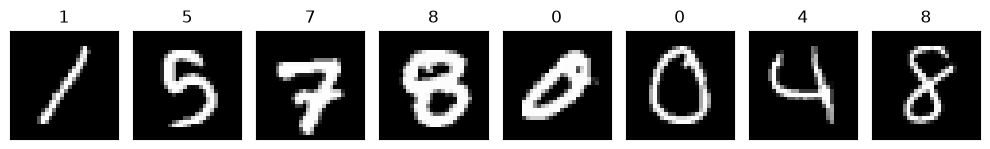

In [74]:
plt.figure(figsize=(10, 4))

for i in range(8):
    ax = plt.subplot(1, 8, i + 1)

    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(str(labels[i].item()))

    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.tight_layout()
plt.show()

# 6. Build the Autoencoder

We now define the Autoencoder architecture.

The network consists of two major components:

### Encoder

The Encoder compresses the 784-dimensional image into a smaller latent representation.

    784 → 256 → 128

### Decoder

The Decoder takes the latent representation and attempts to reconstruct the original image.

    128 → 256 → 784

Therefore, the complete architecture is:

    Input
      ↓
    784
      ↓
    Linear + ReLU
      ↓
    256
      ↓
    Linear + ReLU
      ↓
    128
      ↓
    Latent Representation
      ↓
    Linear + ReLU
      ↓
    256
      ↓
    Linear + Sigmoid
      ↓
    784
      ↓
    Reconstructed Image

### What is the Latent Representation?

The latent representation is the compressed representation learned by the Encoder.

Our original image contains:

    784 values

but the Encoder compresses it into:

    128 values

Therefore:

    784 → 128

This creates a **bottleneck**.

Because the network cannot simply copy every input pixel directly to the output, it is encouraged to learn meaningful features that are useful for reconstruction.

In [75]:
class AutoEncoder(nn.Module):
    def __init__(self, latent_dim=128, hidden_dim=256):
        super().__init__()

        # ---------------------------------------------------------
        # Encoder
        # ---------------------------------------------------------
        # Compress the 784-dimensional input into a smaller
        # latent representation.
        self.encoder = nn.Sequential(
            nn.Linear(784, hidden_dim),   # 784 → 256
            nn.ReLU(),

            nn.Linear(hidden_dim, latent_dim),  # 256 → 128
            nn.ReLU()
        )

        # ---------------------------------------------------------
        # Decoder
        # ---------------------------------------------------------
        # Expand the latent representation back to the original
        # input dimension.
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),  # 128 → 256
            nn.ReLU(),

            nn.Linear(hidden_dim, 784),         # 256 → 784

            # MNIST pixels are in [0, 1], so Sigmoid constrains
            # the reconstructed output to the same range.
            nn.Sigmoid()
        )

    def forward(self, x):
        """
        Forward pass through the complete Autoencoder.

        Input:
            x → flattened MNIST image [batch_size, 784]

        Output:
            reconstructed image [batch_size, 784]
        """

        # Compress the input.
        latent = self.encoder(x)

        # Reconstruct the input from the latent representation.
        reconstruction = self.decoder(latent)

        return reconstruction

## 7. Initialize the Model

We now create an instance of our Autoencoder and move it to the selected device.

We also define:

### Loss Function

We use **Mean Squared Error (MSE)**:

    MSE = mean((x - x_hat)²)

where:

- `x` = original image
- `x_hat` = reconstructed image

The goal is to minimize the difference between them.

### Optimizer

We use **Adam** to update the model's parameters during training.

In [76]:
# Create the Autoencoder and move it to CPU/GPU.
model = AutoEncoder().to(device)

# Reconstruction loss.
criterion = nn.MSELoss()

# Adam optimizer updates the model parameters.
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print(model)

AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=784, bias=True)
    (3): Sigmoid()
  )
)


# 8. Train the Autoencoder

During training, the model performs the following steps:

1. Take a batch of MNIST images.
2. Flatten each image from `28 × 28` into `784`.
3. Pass the images through the Encoder.
4. Obtain the latent representation.
5. Pass the latent representation through the Decoder.
6. Obtain the reconstructed images.
7. Compare reconstruction with the original image.
8. Calculate MSE loss.
9. Backpropagate the loss.
10. Update the model parameters using Adam.

The important difference from classification is that:

    input = target

The model is learning to reconstruct its own input.

In [77]:
# Number of complete passes through the training dataset.
epochs = 20

# Put the model into training mode.
model.train()

for epoch in range(epochs):

    # Store the total loss for this epoch.
    total_loss = 0.0

    for data, _ in train_loader:

        # -----------------------------------------------------
        # 1. Flatten the images
        # -----------------------------------------------------
        # [batch_size, 1, 28, 28]
        #              ↓
        # [batch_size, 784]
        data = data.view(data.size(0), -1).to(device)

        # -----------------------------------------------------
        # 2. Clear gradients from the previous iteration
        # -----------------------------------------------------
        optimizer.zero_grad()

        # -----------------------------------------------------
        # 3. Forward pass
        # -----------------------------------------------------
        # Input → Encoder → Latent Space → Decoder
        output = model(data)

        # -----------------------------------------------------
        # 4. Calculate reconstruction loss
        # -----------------------------------------------------
        loss = criterion(output, data)

        # -----------------------------------------------------
        # 5. Backpropagation
        # -----------------------------------------------------
        loss.backward()

        # -----------------------------------------------------
        # 6. Update model parameters
        # -----------------------------------------------------
        optimizer.step()

        # Accumulate loss for this epoch.
        total_loss += loss.item()

    # Calculate average loss across all batches.
    avg_loss = total_loss / len(train_loader)

    print(
        f"Epoch [{epoch + 1}/{epochs}], "
        f"Loss: {avg_loss:.4f}"
    )

Epoch [1/20], Loss: 0.0416
Epoch [2/20], Loss: 0.0155
Epoch [3/20], Loss: 0.0112
Epoch [4/20], Loss: 0.0090
Epoch [5/20], Loss: 0.0076
Epoch [6/20], Loss: 0.0067
Epoch [7/20], Loss: 0.0060
Epoch [8/20], Loss: 0.0055
Epoch [9/20], Loss: 0.0051
Epoch [10/20], Loss: 0.0048
Epoch [11/20], Loss: 0.0045
Epoch [12/20], Loss: 0.0043
Epoch [13/20], Loss: 0.0041
Epoch [14/20], Loss: 0.0039
Epoch [15/20], Loss: 0.0037
Epoch [16/20], Loss: 0.0036
Epoch [17/20], Loss: 0.0034
Epoch [18/20], Loss: 0.0033
Epoch [19/20], Loss: 0.0032
Epoch [20/20], Loss: 0.0031


# 9. Visualize Reconstructions

After training, we want to answer the most important question:

> **Did the Autoencoder actually learn to reconstruct the images?**

We take images from the dataset and pass them through the trained model.

We then compare:

    Original Image
          ↓
      Autoencoder
          ↓
    Reconstructed Image

The closer the reconstruction looks to the original, the better the Autoencoder has learned the underlying representation.

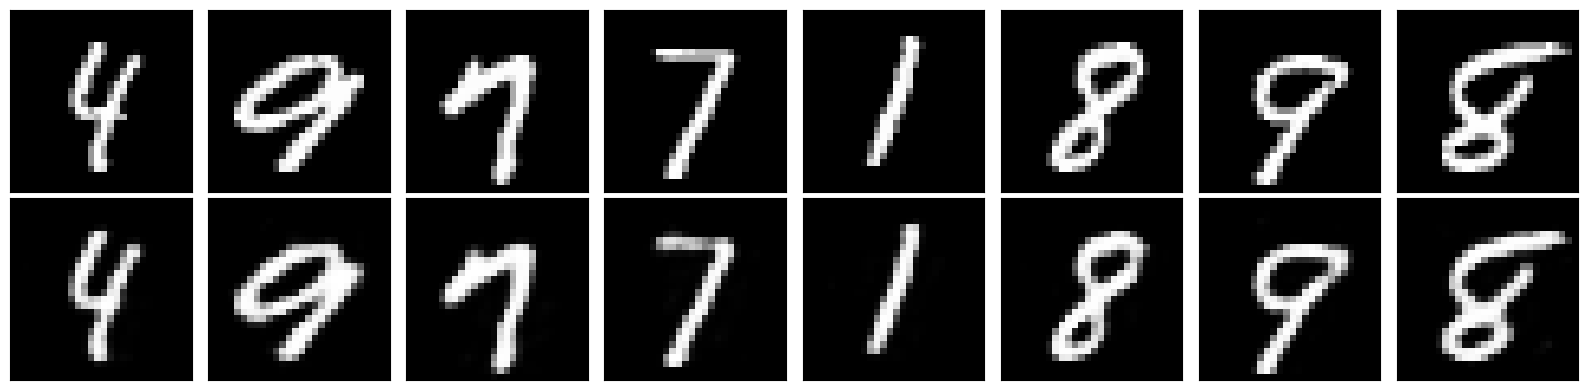

In [78]:
# Switch the model to evaluation mode.
model.eval()

# Disable gradient calculation because we are only performing
# inference and do not need backpropagation.
with torch.no_grad():

    # Get one batch of MNIST images.
    data, _ = next(iter(train_loader))

    # Flatten the images and move them to the selected device.
    data = data.view(data.size(0), -1).to(device)

    # Generate reconstructed images.
    output = model(data)

    # Number of images to display.
    n = 8

    plt.figure(figsize=(16, 4))

    for i in range(n):

        # -----------------------------------------------------
        # Original image
        # -----------------------------------------------------
        ax = plt.subplot(2, n, i + 1)

        plt.imshow(
            data[i].cpu().view(28, 28),
            cmap="gray"
        )

        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

        # -----------------------------------------------------
        # Reconstructed image
        # -----------------------------------------------------
        ax = plt.subplot(2, n, i + 1 + n)

        plt.imshow(
            output[i].cpu().view(28, 28),
            cmap="gray"
        )

        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    plt.tight_layout()
    plt.show()

# 10. Extract the Latent Representations

The most interesting part of an Autoencoder is often not the reconstruction itself, but the **latent space**.

The Encoder transforms every MNIST image:

    784-dimensional image
              ↓
          Encoder
              ↓
    128-dimensional vector

We extract these vectors for the complete training dataset.

Although the Autoencoder was **not trained using digit labels**, we keep the labels here only for visualization.

This allows us to ask:

> Do images of the same digit naturally occupy similar regions of the learned latent space?

In [79]:
# Make sure the model is in evaluation mode.
model.eval()

# Lists to store latent representations and corresponding labels.
latents = []
labels = []

# No gradients are required because we are only extracting
# representations from the trained Encoder.
with torch.no_grad():

    for data, target in train_loader:

        # Flatten images from [B, 1, 28, 28] → [B, 784].
        data = data.view(data.size(0), -1).to(device)

        # Pass images only through the Encoder.
        z = model.encoder(data)

        # Move latent vectors and labels back to CPU
        # before storing them.
        latents.append(z.cpu())
        labels.append(target)

# Combine all batches into one tensor.
latents = torch.cat(latents, dim=0)
labels = torch.cat(labels, dim=0)

print("Latent representation shape:", latents.shape)
print("Labels shape:", labels.shape)

Latent representation shape: torch.Size([60000, 128])
Labels shape: torch.Size([60000])


# 11. Visualize the Latent Space

Our latent representation has 128 dimensions:

    [60000, 128]

Humans cannot directly visualize a 128-dimensional space.

Therefore, we use different visualization strategies depending on the latent dimensionality:

PCA (Principal Component Analysis) reduces the high-dimensional representation to a smaller number of dimensions while attempting to preserve as much variance as possible.

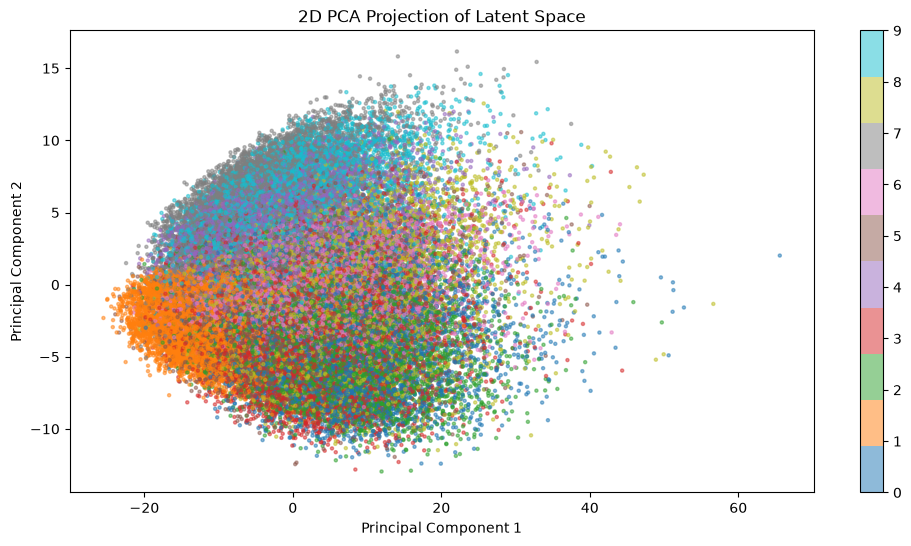

Explained variance ratio: [0.26309752 0.05548924]
Total variance explained: 0.31858677


In [ ]:
from sklearn.decomposition import PCA

# Number of dimensions in the latent representation.
latent_dim = latents.shape[1]

# Convert PyTorch tensors into NumPy arrays for scikit-learn
# and Matplotlib.
z = latents.detach().cpu().numpy()
y = labels.detach().cpu().numpy()

# Since our latent space has more than 3 dimensions,
# use PCA to project it into 2 dimensions.
pca_dim = 2

pca = PCA(
    n_components=pca_dim
)

# Transform the 128-dimensional latent vectors
# into a 2-dimensional representation.
z_pca = pca.fit_transform(z)

plt.figure(figsize=(12, 6))

scatter = plt.scatter(
    z_pca[:, 0],
    z_pca[:, 1],
    c=y,
    cmap="tab10",
    s=5,
    alpha=0.5
)

plt.colorbar(
    scatter,
    ticks=range(10)
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title(
    "2D PCA Projection of Latent Space"
)

plt.show()

# Print how much variance is captured by the
# two principal components.
print(
    "Explained variance ratio:",
    pca.explained_variance_ratio_
    )

print(
    "Total variance explained:",
    pca.explained_variance_ratio_.sum()
)

# 12. What Did We Actually Learn?

Our Autoencoder learned a mapping:

    x → Encoder(x) → z → Decoder(z) → x̂

where:

- `x` = original image
- `z` = latent representation
- `x̂` = reconstructed image

The training objective is:

    minimize MSE(x, x̂)

### Architecture

    Input Image
    28 × 28
       ↓
    Flatten
       ↓
    784
       ↓
    Linear + ReLU
       ↓
    256
       ↓
    Linear + ReLU
       ↓
    128
       ↓
    Latent Space
       ↓
    Linear + ReLU
       ↓
    256
       ↓
    Linear + Sigmoid
       ↓
    784
       ↓
    28 × 28
    Reconstructed Image


### Why is the bottleneck important?

The Encoder is forced to compress 784 values into only 128 values.

This means the model must learn a compact representation containing information that is useful for reconstructing the digit.

This compressed representation is called the **latent representation**.

## 13. Are We Using the MNIST Labels?

No.

During training, the DataLoader gives us:

    image, label

but we intentionally ignore the label:

    for data, _ in train_loader:

The model only sees:

    image → reconstructed image

The digit labels are used later only to color the latent-space visualization.

Therefore, the Autoencoder itself is not explicitly told:

> "This image is a 7."

Instead, it discovers useful structure from the image data itself.

# 14. Key Takeaways

### 1. Autoencoders learn reconstruction

The network tries to reproduce its input.

### 2. The Encoder compresses information

    784 → 128

The resulting vector is the latent representation.

### 3. The Decoder reconstructs the input

    128 → 784

### 4. MSE measures reconstruction quality

Lower reconstruction loss generally means the reconstructed pixels are closer to the original pixels.

### 5. Labels are not required for training

The Autoencoder learns without explicitly using the digit labels.

### 6. Latent space can reveal learned structure

By visualizing the latent representations and coloring them using labels, we can investigate whether different digits occupy different regions.

### 7. PCA helps visualize high-dimensional representations

Our 128-dimensional latent vectors cannot be directly plotted, so PCA projects them into 2D for visualization.

---

## Final Architecture

        Original Image
        28 × 28
           │
           ▼
        Flatten
           │
           ▼
          784
           │
           ▼
      Encoder
     784 → 256
     256 → 128
           │
           ▼
      Latent Space
          128
           │
           ▼
      Decoder
     128 → 256
     256 → 784
           │
           ▼
        Sigmoid
           │
           ▼
    Reconstructed Image
        28 × 28